# Biomedical evidence retrieval with measured abstention

**Portfolio project · MSc Artificial Intelligence · health applications**

Can a small, transparent search system recover a biomedical question's source abstract, and can it reject uncertain source matches? This notebook builds a lexical retrieval benchmark on all 1,000 expert-labeled PubMedQA examples. It compares word and character TF–IDF, selects a hybrid on held-out validation questions, and evaluates a learned acceptance gate on untouched test questions.

The output is a **cited abstract excerpt**, not a generated answer. No language-model API, credentials, local project utilities, or GPU are required. This is a research demonstration, not clinical decision support.

### Evaluation contract

- **Unit:** one PubMedQA question, with its paired PMID as the known source.
- **Corpus:** the context passages from all 1,000 records. The gold source remains in the index; question, title, answer and decision fields are excluded.
- **Split:** 60% train, 20% validation, 20% test questions. Train fits the gate; validation chooses retrieval weight and gate threshold; test is used once after freezing both.
- **Retrieval:** Recall@1, Recall@5 and full-corpus MRR, with query bootstrap intervals and a paired comparison to word TF–IDF.
- **Abstention:** maximize validation coverage subject to at least 95% empirical accepted-source accuracy and 40 accepted validation queries. These are development targets, not guarantees.

TF–IDF learns vocabulary and IDF from the known corpus, including test questions' source documents. This is **held-out-query, fixed-corpus evaluation**, not generalization to unseen documents. Source recovery labels are incomplete relevance judgments: an alternative source may also be relevant.

In [1]:
# Run once in a fresh Python environment if dependencies are missing, then restart the kernel:
# %pip install numpy pandas scipy scikit-learn matplotlib requests

import hashlib
import json
import platform
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 2026
N_BOOTSTRAP = 2000
TARGET_ACCEPTED_ACCURACY = 0.95
MIN_VALIDATION_ACCEPTED = 40
CACHE = Path.cwd() / 'pubmedqa_cache'
CACHE.mkdir(exist_ok=True)
STARTED = time.perf_counter()
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)
print({'python': platform.python_version(), 'numpy': np.__version__,
       'pandas': pd.__version__, 'scikit_learn': sklearn.__version__})

{'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scikit_learn': '1.8.0'}


In [2]:
# Verified source snapshot: content hash makes a cache hit as strict as a fresh download.
SOURCE_URL = 'https://raw.githubusercontent.com/pubmedqa/pubmedqa/1cbae8e92f72f20c8d3747cbb3bf5bc53554d997/data/ori_pqal.json'
SOURCE_COMMIT = '1cbae8e92f72f20c8d3747cbb3bf5bc53554d997'
EXPECTED_SHA256 = '8b3276be8942ebbd77f3ddcda12c1749bf0e490045a736fd8438ee40cf37a41d'
DATA_PATH = CACHE / 'ori_pqal.json'

def fetch_verified(url, destination, expected_sha256):
    if not destination.exists():
        response = requests.get(url, timeout=(10, 90))  # preserves normal proxy/TLS settings
        response.raise_for_status()
        payload = response.content
        actual = hashlib.sha256(payload).hexdigest()
        if actual != expected_sha256:
            raise ValueError('Downloaded content differs from the verified snapshot; review source before updating.')
        destination.write_bytes(payload)
    payload = destination.read_bytes()
    actual = hashlib.sha256(payload).hexdigest()
    if actual != expected_sha256:
        raise ValueError('Cached content hash mismatch. Remove the cache and rerun; no synthetic fallback is used.')
    return payload, actual

payload, actual_sha = fetch_verified(SOURCE_URL, DATA_PATH, EXPECTED_SHA256)
raw = json.loads(payload)
assert isinstance(raw, dict) and len(raw) == 1000
provenance = pd.DataFrame([{'dataset': 'PubMedQA expert-labeled PQA-L', 'records': len(raw),
                          'bytes': len(payload), 'commit': SOURCE_COMMIT,
                          'sha256': actual_sha, 'source': SOURCE_URL}])
display(provenance.T.rename(columns={0: 'snapshot'}))

,snapshot
dataset,PubMedQA expert-labeled PQA-L
records,1000
bytes,2584787
commit,1cbae8e92f72f20c8d3747cbb3bf5bc53554d997
sha256,8b3276be8942ebbd77f3ddcda12c1749bf0e490045a736fd8438ee40cf37a41d
source,https://raw.githubusercontent.com/pubmedqa/pubmedqa/1cbae8e92f72f20c8d3747cbb3bf5bc53554d997/dat...


### Provenance and permitted interpretation

Source: [PubMedQA repository](https://github.com/pubmedqa/pubmedqa), [`data/ori_pqal.json`](https://github.com/pubmedqa/pubmedqa/blob/master/data/ori_pqal.json), and [the paper](https://aclanthology.org/D19-1259/) (Jin et al., EMNLP-IJCNLP 2019). The upstream file is named `ori_pqal.json`; this notebook uses the original 1,000 expert-labeled records rather than a renamed mirror. The byte-level SHA-256 printed above is enforced on every run.

The repository's dataset documentation does not establish blanket redistribution rights to the underlying abstracts; biomedical abstracts retain their respective publishers' rights. Public download availability does not grant blanket redistribution rights to abstracts. This notebook downloads from the upstream source on demand, keeps a local cache, and displays short cited excerpts for inspection. Review upstream terms and publication rights before redistributing data or deploying a product. No personal patient records are used.

In [3]:
def normalize(text):
    return ' '.join(re.findall(r'[a-z0-9]+', str(text).lower()))

rows = []
for pmid, item in sorted(raw.items(), key=lambda pair: int(pair[0])):
    assert {'QUESTION', 'CONTEXTS', 'LONG_ANSWER', 'final_decision'} <= item.keys()
    contexts = item['CONTEXTS']
    assert isinstance(contexts, list) and contexts and all(isinstance(x, str) for x in contexts)
    # Do not concatenate QUESTION, LONG_ANSWER, section labels, or metadata into the index.
    text = '\n'.join(contexts)
    question = item['QUESTION'].strip()
    question_tokens = re.findall(r'[a-z0-9]+', question.lower())
    literal_title_pattern = r'[^a-z0-9]+'.join(map(re.escape, question_tokens))
    # Defensive title/question removal: only a complete question token sequence is removed.
    sanitized, removals = re.subn(literal_title_pattern, '', text, flags=re.IGNORECASE)
    rows.append({'pmid': str(pmid), 'question': question, 'text': sanitized.strip(), 'source_context': text,
                 'decision_for_stratification': item['final_decision'],
                 'question_removals': removals, 'context_passages': len(contexts)})
records = pd.DataFrame(rows)
records['query_group'] = records.question.map(normalize)
records['context_hash'] = records.text.map(lambda s: hashlib.sha256(normalize(s).encode()).hexdigest())
assert records.pmid.is_unique and records.text.str.len().gt(0).all()
assert records.decision_for_stratification.isin(['yes', 'no', 'maybe']).all()
print('Corpus records:', len(records), '| Abstract context passages:', records.context_passages.sum())
display(records[['pmid', 'question', 'context_passages']].head(3))

Corpus records: 1000 | Abstract context passages: 3358


,pmid,question,context_passages
0,1571683,Storage of vaccines in the community: weak link in the cold chain?,6
1,2224269,Should general practitioners call patients by their first names?,6
2,2503176,Inhibin: a new circulating marker of hydatidiform mole?,6


In [4]:
# This audit reports corpus hygiene before any model fitting.
audit = pd.Series({
    'duplicate_normalized_questions': records.query_group.duplicated().sum(),
    'duplicate_contexts': records.context_hash.duplicated().sum(),
    'full_question_sequences_removed': records.question_removals.sum(),
    'empty_contexts': records.text.str.len().eq(0).sum(),
    'own_question_still_in_context': sum(q in normalize(t) for q, t in zip(records.query_group, records.text)),
})
display(audit.to_frame('count'))
assert audit['duplicate_normalized_questions'] == 0, 'Group duplicates before splitting if source changes.'
assert audit['duplicate_contexts'] == 0, 'Deduplicate and redefine gold groups if source changes.'
assert audit['own_question_still_in_context'] == 0
# PMID is kept exclusively for gold scoring and citation lookup, never as an input feature.

,count
duplicate_normalized_questions,0
duplicate_contexts,0
full_question_sequences_removed,0
empty_contexts,0
own_question_still_in_context,0


### Split queries before choosing models

The decision label is used only for stratifying the question split, so each split includes yes/no/maybe questions. It is never predicted, indexed, or supplied as a retrieval feature. The gate's training label is a separate, measurable outcome: whether the selected retriever's top result matches the question's source PMID.

The duplicate audit fails visibly if a changed dataset would violate query independence. Every query contributes at most one row to gate training. The corpus is fixed before fitting either vectorizer.

In [5]:
all_indices = np.arange(len(records))
train_ids, remaining = train_test_split(
    all_indices, test_size=0.4, random_state=SEED,
    stratify=records.decision_for_stratification)
val_ids, test_ids = train_test_split(
    remaining, test_size=0.5, random_state=SEED,
    stratify=records.iloc[remaining].decision_for_stratification)
train_ids, val_ids, test_ids = map(np.sort, (train_ids, val_ids, test_ids))
splits = {'train': train_ids, 'validation': val_ids, 'test': test_ids}
assert (len(train_ids), len(val_ids), len(test_ids)) == (600, 200, 200)
assert all(set(a).isdisjoint(b) for a, b in [(train_ids, val_ids), (train_ids, test_ids), (val_ids, test_ids)])
assert len(set(np.concatenate(list(splits.values())))) == len(records)
display(pd.DataFrame({name: records.iloc[ids].decision_for_stratification.value_counts()
                      for name, ids in splits.items()}).fillna(0).astype(int))
split_fingerprints = {name: hashlib.sha256(','.join(records.iloc[ids].pmid).encode()).hexdigest()
                      for name, ids in splits.items()}
print('Query split fingerprints:', split_fingerprints)

,train,validation,test
decision_for_stratification,,,
yes,331,110,111
no,203,68,67
maybe,66,22,22


Query split fingerprints: {'train': '1a0c5e56380b40c5140b16ce79a9f7a31d47e47eff259d6f2b1c95dc226aef0e', 'validation': '9cc0309f90b8c243e083b554a3fc234d389fd299a07b2671949044770618002f', 'test': 'fd3ef4849f0c63bdd8bc91d0db51ddaddc06032e374e900abaac1a928147e662'}


In [6]:
# Corpus-only fit. No stop-word list: negation terms such as 'not' remain available.
word_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2,
                                 sublinear_tf=True, norm='l2', dtype=np.float32)
char_vectorizer = TfidfVectorizer(lowercase=True, analyzer='char_wb', ngram_range=(3, 5),
                                 min_df=2, max_features=120_000, sublinear_tf=True,
                                 norm='l2', dtype=np.float32)
word_docs = word_vectorizer.fit_transform(records.text)
char_docs = char_vectorizer.fit_transform(records.text)
print('Word index:', word_docs.shape, '| Character index:', char_docs.shape)
assert word_docs.shape[0] == char_docs.shape[0] == 1000

Word index: (1000, 24207) | Character index: (1000, 57884)


### Transparent ranking and tuning

Word n-grams reward lexical matches; character n-grams can tolerate inflection, spelling differences and partially shared biomedical terms. Neither model understands biomedical equivalence or contradiction. A hybrid score is `word_weight × word_cosine + (1 − word_weight) × character_cosine`.

Five weights are specified in advance. Validation Recall@1 chooses the retriever; validation full MRR breaks ties, then the larger word weight provides a deterministic final tie-break. Retrieval depth is fixed at five for displayed candidates and Recall@5. Ranking uses all 1,000 documents and deterministic corpus-order ties.

In [7]:
def component_scores(questions):
    word_queries = word_vectorizer.transform(questions)
    char_queries = char_vectorizer.transform(questions)
    return ((word_queries @ word_docs.T).toarray(),
            (char_queries @ char_docs.T).toarray())

def rank_scores(scores):
    return np.argsort(-scores, axis=1, kind='stable')

def gold_ranks(ranking, gold_document_ids):
    matches = ranking == np.asarray(gold_document_ids)[:, None]
    assert matches.sum(axis=1).min() == matches.sum(axis=1).max() == 1
    return np.argmax(matches, axis=1) + 1

def metric_values(ranks):
    ranks = np.asarray(ranks)
    return {'Recall@1': np.mean(ranks <= 1), 'Recall@5': np.mean(ranks <= 5),
            'MRR': np.mean(1.0 / ranks)}

def gate_features(scores, ranking):
    top_two = np.take_along_axis(scores, ranking[:, :2], axis=1)
    return np.column_stack([top_two[:, 0], top_two[:, 0] - top_two[:, 1]])

val_word, val_char = component_scores(records.iloc[val_ids].question)
WEIGHTS = [1.0, 0.75, 0.5, 0.25, 0.0]
validation_rows = []
for weight in WEIGHTS:
    ranks = gold_ranks(rank_scores(weight * val_word + (1-weight) * val_char), val_ids)
    validation_rows.append({'word_weight': weight, **metric_values(ranks)})
validation_results = pd.DataFrame(validation_rows).sort_values(
    ['Recall@1', 'MRR', 'word_weight'], ascending=False).reset_index(drop=True)
SELECTED_WEIGHT = float(validation_results.iloc[0].word_weight)
display(validation_results)
print('Selected word weight on validation:', SELECTED_WEIGHT)

,word_weight,Recall@1,Recall@5,MRR
0,0.25,0.945,0.985,0.962653
1,0.50,0.940,0.975,0.953817
2,0.00,0.930,0.985,0.955884
3,0.75,0.915,0.965,0.937571
4,1.00,0.885,0.945,0.912823


Selected word weight on validation: 0.25


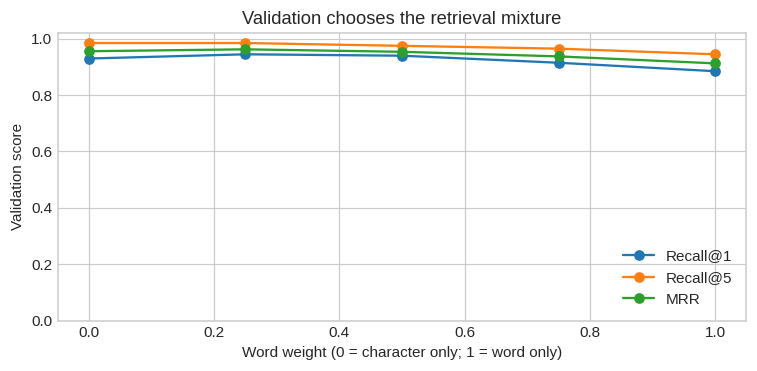

In [8]:
plot_table = validation_results.sort_values('word_weight')
fig, ax = plt.subplots(figsize=(7, 3.5))
for metric in ['Recall@1', 'Recall@5', 'MRR']:
    ax.plot(plot_table.word_weight, plot_table[metric], marker='o', label=metric)
ax.set(xlabel='Word weight (0 = character only; 1 = word only)', ylabel='Validation score',
       title='Validation chooses the retrieval mixture', ylim=(0, 1.02))
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

### Learn when to accept a source match

The gate uses two observable retrieval features: the top cosine mixture score and the gap between first and second place. A standardized logistic regression learns top-1 source correctness from **train queries only**. This is a gate score, not a calibrated confidence in a medical claim.

After training, the validation threshold maximizes coverage subject to the predeclared accuracy and minimum-count targets. If no threshold qualifies, the system abstains on all queries. Reusing validation for retrieval and threshold selection may overfit that development split; only the frozen test evaluation estimates the final procedure's performance.

In [9]:
train_word, train_char = component_scores(records.iloc[train_ids].question)
train_scores = SELECTED_WEIGHT * train_word + (1-SELECTED_WEIGHT) * train_char
train_ranking = rank_scores(train_scores)
train_correct = (train_ranking[:, 0] == train_ids).astype(int)
assert len(np.unique(train_correct)) == 2, 'A supervised gate needs both source outcomes.'
gate = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
gate.fit(gate_features(train_scores, train_ranking), train_correct)
val_scores = SELECTED_WEIGHT * val_word + (1-SELECTED_WEIGHT) * val_char
val_ranking = rank_scores(val_scores)
val_correct = val_ranking[:, 0] == val_ids
val_gate_scores = gate.predict_proba(gate_features(val_scores, val_ranking))[:, 1]
print('Training source outcomes:', dict(zip(*np.unique(train_correct, return_counts=True))))
print('Gate coefficients for standardized [top score, margin]:', gate[-1].coef_[0].round(3))

Training source outcomes: {np.int64(0): np.int64(33), np.int64(1): np.int64(567)}
Gate coefficients for standardized [top score, margin]: [0.779 2.852]


In [10]:
def selective_metrics(correct, accepted):
    correct, accepted = np.asarray(correct, bool), np.asarray(accepted, bool)
    n, accepted_n = len(correct), int(accepted.sum())
    return {'total': n, 'accepted': accepted_n, 'coverage': accepted_n/n,
            'accepted_source_accuracy': float(correct[accepted].mean()) if accepted_n else np.nan,
            'wrong_accepts_per_query': float(np.mean(accepted & ~correct)),
            'correct_accepts_per_query': float(np.mean(accepted & correct))}

threshold_rows = []
for threshold in np.r_[0.0, np.unique(val_gate_scores), np.inf]:
    threshold_rows.append({'threshold': threshold,
                           **selective_metrics(val_correct, val_gate_scores >= threshold)})
threshold_table = pd.DataFrame(threshold_rows)
qualifying = threshold_table[
    (threshold_table.accepted >= MIN_VALIDATION_ACCEPTED) &
    (threshold_table.accepted_source_accuracy >= TARGET_ACCEPTED_ACCURACY)]
if qualifying.empty:
    SELECTED_THRESHOLD = np.inf
else:
    SELECTED_THRESHOLD = float(qualifying.sort_values(['coverage', 'threshold'],
                                                      ascending=[False, True]).iloc[0].threshold)
val_operating_point = selective_metrics(val_correct, val_gate_scores >= SELECTED_THRESHOLD)
print('Selected threshold on validation:', SELECTED_THRESHOLD)
display(pd.DataFrame([{'policy': 'accept all validation', **selective_metrics(val_correct, np.ones(200, bool))},
                      {'policy': 'frozen validation gate', **val_operating_point}]))
# Freeze all choices before accessing test retrieval scores.
frozen_design = {'word_weight': SELECTED_WEIGHT, 'threshold': SELECTED_THRESHOLD,
                 'target_accuracy': TARGET_ACCEPTED_ACCURACY,
                 'min_validation_accepted': MIN_VALIDATION_ACCEPTED, 'retrieval_depth': 5}

Selected threshold on validation: 0.40695876224702343


,policy,total,accepted,coverage,accepted_source_accuracy,wrong_accepts_per_query,correct_accepts_per_query
0,accept all validation,200,200,1.00,0.945000,0.055,0.945
1,frozen validation gate,200,198,0.99,0.954545,0.045,0.945


### One untouched test evaluation

Intervals below use 2,000 deterministic nonparametric bootstrap resamples of the 200 test questions. They describe sampling uncertainty within this benchmark, conditional on the fixed corpus and fitted pipeline; they do not include dataset shift or hyperparameter-selection uncertainty. The word and character baselines were specified before testing. No test result changes the selected configuration.

In [11]:
def bootstrap_mean(values, seed=SEED):
    values = np.asarray(values, float)
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, len(values), size=(N_BOOTSTRAP, len(values)))
    means = values[draws].mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]))

test_word, test_char = component_scores(records.iloc[test_ids].question)
TEST_CONFIGS = {'word TF-IDF': 1.0, 'character TF-IDF': 0.0, 'validation-selected mixture': SELECTED_WEIGHT}
test_rank_arrays = {}
test_rows = []
for name, weight in TEST_CONFIGS.items():
    ranking = rank_scores(weight * test_word + (1-weight) * test_char)
    ranks = gold_ranks(ranking, test_ids)
    test_rank_arrays[name] = ranks
    outcomes = {'Recall@1': ranks <= 1, 'Recall@5': ranks <= 5, 'MRR': 1/ranks}
    for metric, values in outcomes.items():
        low, high = bootstrap_mean(values)
        test_rows.append({'retriever': name, 'metric': metric, 'estimate': np.mean(values),
                          '95% CI low': low, '95% CI high': high})
test_results = pd.DataFrame(test_rows)
display(test_results.round(4))
selected_ranks = test_rank_arrays['validation-selected mixture']
word_ranks = test_rank_arrays['word TF-IDF']
paired_delta = (selected_ranks <= 1).astype(float) - (word_ranks <= 1).astype(float)
print('Paired test Recall@1 difference, selected minus word:', round(paired_delta.mean(), 4),
      '| bootstrap 95% interval:', tuple(round(x, 4) for x in bootstrap_mean(paired_delta)))

,retriever,metric,estimate,95% CI low,95% CI high
0,word TF-IDF,Recall@1,0.8500,0.8000,0.8950
1,word TF-IDF,Recall@5,0.9650,0.9400,0.9850
2,word TF-IDF,MRR,0.9053,0.8710,0.9368
3,character TF-IDF,Recall@1,0.9450,0.9100,0.9750
4,character TF-IDF,Recall@5,0.9900,0.9750,1.0000
5,character TF-IDF,MRR,0.9633,0.9403,0.9827
6,validation-selected mixture,Recall@1,0.9500,0.9150,0.9750
7,validation-selected mixture,Recall@5,0.9900,0.9750,1.0000
8,validation-selected mixture,MRR,0.9678,0.9455,0.9852


Paired test Recall@1 difference, selected minus word: 0.1 | bootstrap 95% interval: (np.float64(0.055), np.float64(0.145))


,policy,total,accepted,coverage,accepted_source_accuracy,wrong_accepts_per_query,correct_accepts_per_query
0,accept all test,200,200,1.000,0.9500,0.050,0.95
1,frozen gate test,200,199,0.995,0.9548,0.045,0.95


Test coverage 95% interval: (np.float64(0.985), np.float64(1.0))
Accepted source accuracy 95% interval: (np.float64(0.9246), np.float64(0.9799))


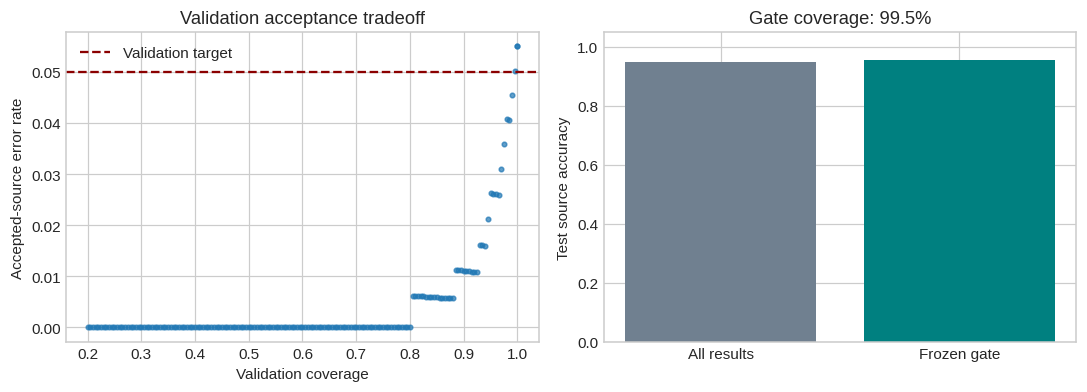

In [12]:
test_scores = SELECTED_WEIGHT * test_word + (1-SELECTED_WEIGHT) * test_char
test_ranking = rank_scores(test_scores)
test_correct = test_ranking[:, 0] == test_ids
test_gate_scores = gate.predict_proba(gate_features(test_scores, test_ranking))[:, 1]
test_accepted = test_gate_scores >= SELECTED_THRESHOLD
test_gate_metrics = selective_metrics(test_correct, test_accepted)
display(pd.DataFrame([{'policy': 'accept all test', **selective_metrics(test_correct, np.ones(200, bool))},
                      {'policy': 'frozen gate test', **test_gate_metrics}]).round(4))

# Bootstrap accepted accuracy and coverage jointly by resampling entire queries.
rng = np.random.default_rng(SEED)
resampled = rng.integers(0, len(test_ids), size=(N_BOOTSTRAP, len(test_ids)))
accepted_counts = test_accepted[resampled].sum(axis=1)
correct_accepted_counts = (test_accepted & test_correct)[resampled].sum(axis=1)
boot_accuracy = np.divide(correct_accepted_counts, accepted_counts,
                          out=np.full(N_BOOTSTRAP, np.nan), where=accepted_counts > 0)
print('Test coverage 95% interval:', tuple(np.quantile(accepted_counts / len(test_ids), [0.025, 0.975]).round(4)))
print('Accepted source accuracy 95% interval:',
      tuple(np.nanquantile(boot_accuracy, [0.025, 0.975]).round(4)) if np.isfinite(boot_accuracy).any() else 'undefined')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
curve = threshold_table[threshold_table.accepted >= MIN_VALIDATION_ACCEPTED]
axes[0].plot(curve.coverage, 1-curve.accepted_source_accuracy, '.', alpha=.7)
axes[0].axhline(1-TARGET_ACCEPTED_ACCURACY, color='darkred', linestyle='--', label='Validation target')
axes[0].set(xlabel='Validation coverage', ylabel='Accepted-source error rate', title='Validation acceptance tradeoff')
axes[0].legend()
labels = ['All results', 'Frozen gate']
axes[1].bar(labels, [test_correct.mean(), test_gate_metrics['accepted_source_accuracy']], color=['slategray', 'teal'])
axes[1].set(ylabel='Test source accuracy', ylim=(0, 1.05), title=f'Gate coverage: {test_gate_metrics["coverage"]:.1%}')
plt.tight_layout(); plt.show()

### Inspect retrieval errors and terminology limitations

The following errors are selected automatically by largest gold-source rank, rather than handpicked to make the system look good. Overlap counts help inspect lexical behavior; they are not evidence-quality scores. Character matching can link word forms but does not resolve synonyms such as *myocardial infarction* and *heart attack*. Biomedical concept normalization or dense retrieval would need a separately evaluated extension.

Alternative retrieved abstracts are labeled source mismatches only against the paired PMID. Without pooled human relevance judgments, these are not all proven irrelevant documents.

In [13]:
test_analysis = records.iloc[test_ids][['pmid', 'question']].reset_index(drop=True)
test_analysis['retrieved_pmid'] = records.iloc[test_ranking[:, 0]].pmid.to_numpy()
test_analysis['gold_rank'] = selected_ranks
test_analysis['gate_score'] = test_gate_scores
test_analysis['accepted'] = test_accepted
test_analysis['word_gold_rank'] = word_ranks
errors = test_analysis[test_analysis.gold_rank > 1].sort_values('gold_rank', ascending=False)
print('Top-1 test source mismatches:', len(errors), '| Wrong accepted source matches:', int((test_accepted & ~test_correct).sum()))
display(errors.head(8))
improvements = test_analysis[(test_analysis.word_gold_rank > 1) & (test_analysis.gold_rank == 1)]
print('Mixture recovers sources missed at word top-1:', len(improvements))
display(improvements.head(3))

Top-1 test source mismatches: 10 | Wrong accepted source matches: 9


,pmid,question,retrieved_pmid,gold_rank,gate_score,accepted,word_gold_rank
96,20064872,Can the prognosis of polymyalgia rheumatica be predicted at disease onset?,10783841,219,0.484612,True,659
78,18359123,Is it better to be big?,17208539,44,0.292971,False,294
105,20674150,Validation of the 2009 TNM version in a large multi-institutional cohort of patients treated for...,17489316,5,0.512643,True,8
80,18540901,Transient tachypnea of the newborn (TTN): a role for polymorphisms in the beta-adrenergic recept...,22324545,3,0.723024,True,2
108,21194998,Does minimal access major surgery in the newborn hurt less?,15041506,2,0.488811,True,2
128,23321509,Quaternary cytoreductive surgery in ovarian cancer: does surgical effort still matter?,24191126,2,0.741028,True,3
143,24599411,Is gastric cancer different in Korea and the United States?,20082356,2,0.588075,True,14
164,25859857,Could the extent of lymphadenectomy be modified by neoadjuvant chemotherapy in cervical cancer?,23177368,2,0.524311,True,1


Mixture recovers sources missed at word top-1: 22


,pmid,question,retrieved_pmid,gold_rank,gate_score,accepted,word_gold_rank
2,8916748,Do socioeconomic differences in mortality persist after retirement?,8916748,1,0.995434,True,2
5,9616411,Do general practitioner hospitals reduce the utilisation of general hospital beds?,9616411,1,0.949555,True,2
11,10759659,The nurse cystoscopist: a feasible option?,10759659,1,0.982323,True,3


In [14]:
def excerpt_for_query(query, document_id, maximum_chars=420):
    # Extract a verbatim sentence/window; do not paraphrase or fabricate an answer.
    text = records.iloc[int(document_id)].source_context
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
    query_tokens = set(normalize(query).split())
    chosen = max(sentences, key=lambda s: len(query_tokens & set(normalize(s).split())))
    excerpt = chosen[:maximum_chars]
    assert excerpt in text
    return excerpt

def show_cited_result(test_position):
    position = int(test_position)
    query = records.iloc[test_ids[position]].question
    document_id = int(test_ranking[position, 0])
    pmid = records.iloc[document_id].pmid
    status = 'ACCEPTED candidate source' if test_accepted[position] else 'ABSTAIN: candidate shown only for audit'
    citation = f'https://pubmed.ncbi.nlm.nih.gov/{pmid}/'
    display(Markdown(f'**{status}**  \nQuestion: {query}  \n[PMID {pmid}]({citation}) · paired-source rank {selected_ranks[position]} · gate score {test_gate_scores[position]:.3f}'))
    print('Verbatim source-context excerpt:', excerpt_for_query(query, document_id))

# Show one correct match and the worst source mismatch, where available.
correct_positions = np.flatnonzero(test_correct)
if len(correct_positions):
    show_cited_result(correct_positions[0])
if len(errors):
    show_cited_result(np.argmax(selected_ranks))

**ACCEPTED candidate source**  
Question: Necrotizing fasciitis: an indication for hyperbaric oxygenation therapy?  
[PMID 7482275](https://pubmed.ncbi.nlm.nih.gov/7482275/) · paired-source rank 1 · gate score 0.811

Verbatim source-context excerpt: Hyperbaric oxygenation (HBO) has been recommended as adjuvant therapy for NF, improving patient mortality and outcome.


**ACCEPTED candidate source**  
Question: Can the prognosis of polymyalgia rheumatica be predicted at disease onset?  
[PMID 10783841](https://pubmed.ncbi.nlm.nih.gov/10783841/) · paired-source rank 219 · gate score 0.485

Verbatim source-context excerpt: 1,412 individuals attending the University of Queensland's School of Dentistry were assessed for the prevalence of periodontal disease and rheumatoid arthritis.


### Small manually authored challenge set

These eight queries were written as a qualitative stress test: four plainly outside this abstract corpus and four biomedical vocabulary/claim probes. They have no gold relevance judgments. They are evaluated only after the design is frozen and are never used to tune it.

For the clearly unrelated queries, acceptance is an obvious corpus-domain failure. For the biomedical probes, acceptance alone does not establish that the excerpt answers the question. This small set cannot estimate real-world OOD performance, medical correctness, sensitivity to all synonyms, or safe abstention.

In [15]:
challenge = pd.DataFrame([
    ('unrelated', 'How should I debug a JavaScript promise that rejects in a web browser?'),
    ('unrelated', 'What is the best recipe for sourdough bread with rye flour?'),
    ('unrelated', 'Who won the football World Cup in 2022?'),
    ('unrelated', 'How can I replace the timing belt in a diesel car engine?'),
    ('biomedical probe', 'Does treatment after a heart attack reduce later heart failure?'),
    ('biomedical probe', 'Does treatment after myocardial infarction reduce later cardiac failure?'),
    ('biomedical probe', 'Do all antibiotics cure viral respiratory infections?'),
    ('biomedical probe', 'Can a single normal blood test rule out every cancer?'),
], columns=['kind', 'question'])
challenge_word, challenge_char = component_scores(challenge.question)
challenge_scores = SELECTED_WEIGHT * challenge_word + (1-SELECTED_WEIGHT) * challenge_char
challenge_ranking = rank_scores(challenge_scores)
challenge['gate_score'] = gate.predict_proba(gate_features(challenge_scores, challenge_ranking))[:, 1]
challenge['accepted'] = challenge.gate_score >= SELECTED_THRESHOLD
challenge['retrieved_pmid'] = records.iloc[challenge_ranking[:, 0]].pmid.to_numpy()
challenge['verbatim_excerpt'] = [excerpt_for_query(q, idx, maximum_chars=200)
                                 for q, idx in zip(challenge.question, challenge_ranking[:, 0])]
display(challenge)
print('Unrelated-query acceptances:', int(challenge.loc[challenge.kind.eq('unrelated'), 'accepted'].sum()), '/ 4')
# Compare term variants descriptively; there is no gold source for this manually authored pair.
print('Heart-attack / myocardial-infarction variant top-5 PMID overlap:',
      len(set(challenge_ranking[4, :5]) & set(challenge_ranking[5, :5])), '/ 5')

,kind,question,gate_score,accepted,retrieved_pmid,verbatim_excerpt
0,unrelated,How should I debug a JavaScript promise that rejects in a web browser?,0.323021,False,26518378,"In the final ordinal regression model, the unadjusted OR for the manuscript desirability score w..."
1,unrelated,What is the best recipe for sourdough bread with rye flour?,0.285675,False,21914194,This study assessed the views and values of professionals working in different health care conte...
2,unrelated,Who won the football World Cup in 2022?,0.387787,False,24153338,"With the advancement of an aging society in the world, an increasing number of elderly patients ..."
3,unrelated,How can I replace the timing belt in a diesel car engine?,0.333183,False,22440363,This was a study to compare the results of mitral valve (MV) repair and MV replacement for the t...
4,biomedical probe,Does treatment after a heart attack reduce later heart failure?,0.386741,False,17224424,Trained individuals showed a lower heart rate and a higher heart rate variability than sedentary...
5,biomedical probe,Does treatment after myocardial infarction reduce later cardiac failure?,0.705484,True,12040336,Patients admitted to hospitals with revascularization services were more likely to undergo coron...
6,biomedical probe,Do all antibiotics cure viral respiratory infections?,0.588034,True,27096199,To correlate the presence of viral co-infection with clinical phenotype in children admitted wit...
7,biomedical probe,Can a single normal blood test rule out every cancer?,0.546467,True,10811329,"Of a population of 313 children who had a 99mTc-WBC scan, 130 children were studied exclusively ..."


Unrelated-query acceptances: 0 / 4
Heart-attack / myocardial-infarction variant top-5 PMID overlap: 0 / 5


In [16]:
selected_metrics = metric_values(selected_ranks)
print(f'Finding: validation selected word weight {SELECTED_WEIGHT:.2f}. On 200 test queries, '
      f'Recall@1={selected_metrics["Recall@1"]:.3f}, Recall@5={selected_metrics["Recall@5"]:.3f}, '
      f'full MRR={selected_metrics["MRR"]:.3f}.')
accepted_accuracy = test_gate_metrics['accepted_source_accuracy']
accuracy_text = f'{accepted_accuracy:.3f}' if np.isfinite(accepted_accuracy) else 'undefined'
print(f'Finding: the frozen gate accepted {test_gate_metrics["accepted"]}/200 queries '
      f'(coverage={test_gate_metrics["coverage"]:.3f}), with accepted source accuracy={accuracy_text}; '
      f'wrong accepts per query={test_gate_metrics["wrong_accepts_per_query"]:.3f}.')
print(f'Finding: the challenge set accepted {int(challenge.loc[challenge.kind.eq("unrelated"), "accepted"].sum())}'
      ' of 4 unrelated queries; this is a qualitative stress result, not a distributional estimate.')
print('Elapsed notebook runtime, seconds:', round(time.perf_counter()-STARTED, 1))

Finding: validation selected word weight 0.25. On 200 test queries, Recall@1=0.950, Recall@5=0.990, full MRR=0.968.
Finding: the frozen gate accepted 199/200 queries (coverage=0.995), with accepted source accuracy=0.955; wrong accepts per query=0.045.
Finding: the challenge set accepted 0 of 4 unrelated queries; this is a qualitative stress result, not a distributional estimate.
Elapsed notebook runtime, seconds: 4.7


### Limits and next experiment

All benchmark queries have a paired source inside a small corpus. This favors source recovery and does not test retrieval over all PubMed, document drift, truly unanswerable questions, evidence contradictions, study quality, or medical answer factuality. Question phrasing originates from article titles, which may share vocabulary with abstracts even though titles are excluded. The query bootstrap treats questions as independent; topic or publication dependence may make intervals optimistic.

The logistic gate is trained on benchmark source correctness. Its scores are not claim-verification probabilities, and its validation accuracy target can fail on test or under shift. Inspect both the coverage and wrong-accept rate; an abstain-all result is permissible and must remain visible. The manual challenge set is tiny and intentionally difficult to interpret for biomedical queries.

A next experiment would freeze this evaluation protocol, add biomedical synonym normalization and a locally run dense retriever, and obtain pooled human relevance judgments plus a separate unsupported-question benchmark. That extension should report retrieval, evidence adequacy and answer correctness as separate outcomes.

In [17]:
# Executable audit trail: fail visibly when provenance, independence or output contracts break.
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == EXPECTED_SHA256
assert records.pmid.is_unique and len(records) == 1000
assert set(train_ids).isdisjoint(val_ids) and set(train_ids).isdisjoint(test_ids) and set(val_ids).isdisjoint(test_ids)
assert SELECTED_WEIGHT in WEIGHTS
assert frozen_design['word_weight'] == SELECTED_WEIGHT and frozen_design['threshold'] == SELECTED_THRESHOLD
assert test_ranking.shape == (200, 1000) and len(test_gate_scores) == 200
assert np.all((selected_ranks >= 1) & (selected_ranks <= 1000))
assert np.isfinite(test_scores).all() and np.isfinite(test_gate_scores).all()
assert test_gate_metrics['accepted'] == int(test_accepted.sum())
assert np.isclose(test_gate_metrics['wrong_accepts_per_query'] + test_gate_metrics['correct_accepts_per_query'],
                  test_gate_metrics['coverage'])
for q, doc_id in zip(challenge.question, challenge_ranking[:, 0]):
    assert excerpt_for_query(q, doc_id) in records.iloc[int(doc_id)].source_context
print('All provenance, split, ranking, acceptance and verbatim-excerpt assertions passed.')

All provenance, split, ranking, acceptance and verbatim-excerpt assertions passed.
